---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/NumPy-013243?style=for-the-badge&logo=numpy&logoColor=white"/>
</div>

---

## Organização deste notebook

| Parte | Conteúdo |
|-------|----------|
| **1** | O neurônio artificial: biologia → matemática → código |
| **2** | FNN vs MLP — qual a diferença? |
| **3** | Exemplo de Regressão com MLP (NumPy do zero) |
| **4** | Exemplo de Classificação com MLP (NumPy do zero) |
| **5** | Conclusão e comparação de resultados |

> **Objetivo:** construir do zero toda a base matemática e computacional de redes totalmente conectadas antes de usar frameworks como PyTorch.

In [1]:
#%pip install numpy matplotlib torch --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
torch.manual_seed(42)
print(f"NumPy {np.__version__} | PyTorch {torch.__version__}")

NumPy 2.4.4 | PyTorch 2.11.0


## <span style="color:#1E90FF;">1. O Neurônio Artificial</span>

### Da biologia à matemática

O **neurônio biológico** recebe sinais elétricos por seus dendritos, os integra no corpo celular e, se o somatório ultrapassar um limiar, dispara um sinal pelo axônio.

O **neurônio artificial** segue a mesma lógica em três etapas:

| Etapa | Biologia | Matemática |
|-------|----------|------------|
| Recepção | Dendritos recebem sinais | $x_1, x_2, \ldots, x_n$ (entradas) |
| Integração | Corpo celular soma sinais ponderados | $z = \sum_{i} w_i x_i + b$ |
| Ativação | Axônio dispara (ou não) | $\hat{y} = \sigma(z)$ |

A **função de ativação** $\sigma$ controla quando e como o neurônio "dispara". As mais comuns:

$$\text{Sigmoid: } \sigma(z) = \frac{1}{1 + e^{-z}} \qquad \text{ReLU: } \sigma(z) = \max(0, z) \qquad \text{Tanh: } \sigma(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$$

Entradas  x  = [ 0.5 -1.2  0.8]
Pesos     w  = [ 0.9  0.4 -0.7]
Bias      b  = 0.1
Soma       z = w·x + b = -0.4900
Ativação   â = σ(z)   = 0.3799


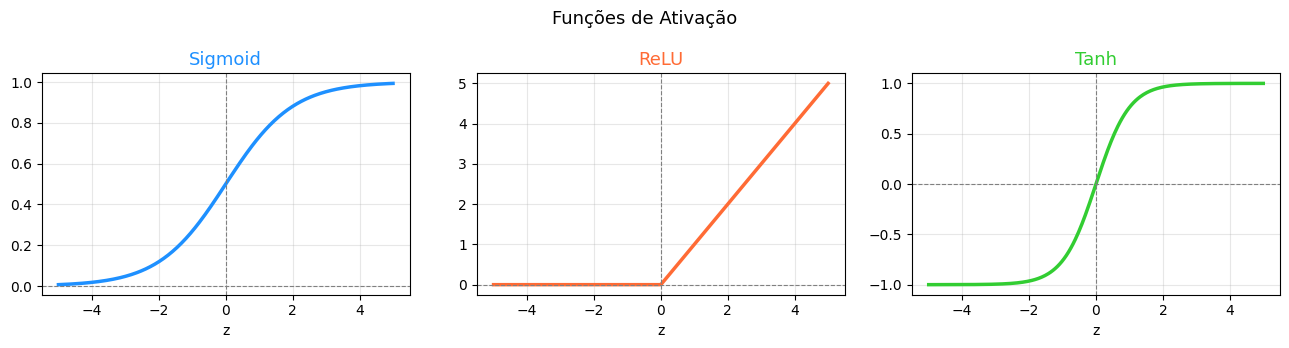

In [3]:
# ── Funções de ativação ──────────────────────────────────────────────────────
def sigmoid(z): return 1 / (1 + np.exp(-z))
def relu(z):    return np.maximum(0, z)
def tanh(z):    return np.tanh(z)

# ── Neurônio único ────────────────────────────────────────────────────────────
def neuronio(x, w, b, ativacao=sigmoid):
    z = np.dot(w, x) + b
    a = ativacao(z)
    return z, a

# ── Exemplo: neurônio com 3 entradas ─────────────────────────────────────────
x = np.array([0.5, -1.2, 0.8])
w = np.array([0.9,  0.4, -0.7])
b = 0.1

z, a = neuronio(x, w, b, sigmoid)
print(f"Entradas  x  = {x}")
print(f"Pesos     w  = {w}")
print(f"Bias      b  = {b}")
print(f"Soma       z = w·x + b = {z:.4f}")
print(f"Ativação   â = σ(z)   = {a:.4f}")

# ── Visualização das funções de ativação ──────────────────────────────────────
z_vals = np.linspace(-5, 5, 300)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, fn, nome, cor in [
    (axes[0], sigmoid, 'Sigmoid',  '#1E90FF'),
    (axes[1], relu,    'ReLU',     '#FF6B35'),
    (axes[2], tanh,    'Tanh',     '#32CD32'),
]:
    ax.plot(z_vals, fn(z_vals), color=cor, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(nome, fontsize=13, color=cor)
    ax.set_xlabel('z'); ax.grid(True, alpha=0.3)
plt.suptitle('Funções de Ativação', fontsize=13)
plt.tight_layout()
plt.show()

---

## <span style="color:#1E90FF;">2. FNN vs MLP, qual a Diferença?</span>

Na prática os dois termos descrevem **a mesma arquitetura**: camadas onde todos os neurônios de uma camada se conectam a todos os da próxima (*fully connected*).

| Aspecto | FNN (Fully Connected NN) | MLP (Multi-Layer Perceptron) |
|---------|--------------------------|------------------------------|
| Origem | Terminologia moderna | Terminologia clássica (anos 80) |
| Arquitetura | Camadas densas empilhadas | Camadas densas empilhadas |
| Sinonímia | = MLP | = FNN |
| Uso típico | Contexto de CNNs/RNNs (últimas camadas) | Literatura acadêmica clássica |

### Arquitetura geral

$$\underbrace{x \in \mathbb{R}^{d}}_{\text{entrada}} \xrightarrow{W^{(1)}, b^{(1)}} h^{(1)} \xrightarrow{W^{(2)}, b^{(2)}} h^{(2)} \xrightarrow{\cdots} \xrightarrow{W^{(L)}, b^{(L)}} \underbrace{\hat{y}}_{\text{saída}}$$

Cada camada $l$ computa:

$$h^{(l)} = \sigma\!\left(W^{(l)}\, h^{(l-1)} + b^{(l)}\right)$$

A diferença real entre modelos está no **número de camadas**, **tamanho**, **função de ativação** e **função de perda** — não no nome.

---

## <span style="color:#1E90FF;">3. Exemplo 1: Regressão com MLP</span>

### Problema

Queremos que a rede aprenda a aproximar a função:

$$y = \sin(2\pi x) + \epsilon, \quad x \in [0, 1], \quad \epsilon \sim \mathcal{N}(0, 0.1)$$

Isso é uma tarefa de **regressão**: a saída é contínua.

### Arquitetura

```
Entrada (1) → Camada 1 (16 neurônios, Tanh) → Camada 2 (16 neurônios, Tanh) → Saída (1, linear)
```

### Função de Perda: MSE

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left(\hat{y}_i - y_i\right)^2$$

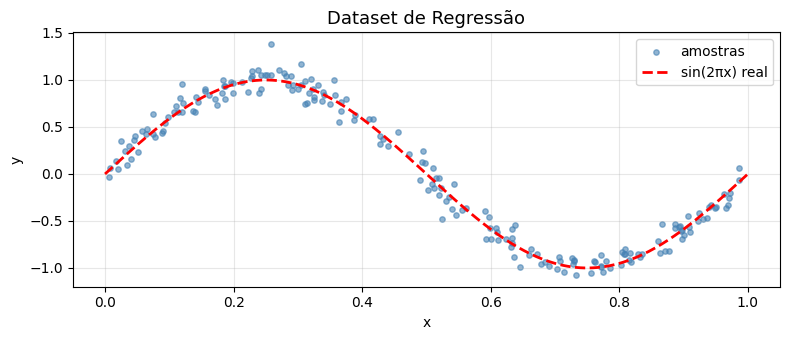

Dataset: 200 amostras


In [4]:
# ── Dataset: y = sin(2πx) + ruído ────────────────────────────────────────────
N = 200
X_reg = np.sort(np.random.uniform(0, 1, N)).reshape(-1, 1)
y_reg = np.sin(2 * np.pi * X_reg).ravel() + np.random.normal(0, 0.1, N)

# Normalização da entrada
X_reg_n = (X_reg - X_reg.mean()) / X_reg.std()

plt.figure(figsize=(8, 3.5))
plt.scatter(X_reg, y_reg, s=15, alpha=0.6, color='steelblue', label='amostras')
x_true = np.linspace(0, 1, 300)
plt.plot(x_true, np.sin(2 * np.pi * x_true), 'r--', linewidth=2, label='sin(2πx) real')
plt.title('Dataset de Regressão', fontsize=13)
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Dataset: {N} amostras')

In [5]:
# ── MLP com PyTorch ───────────────────────────────────────────────────────────
class MLPReg(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),           # saída linear (regressão)
        )

    def forward(self, x):
        return self.net(x)

# Converte dataset para tensores
X_t = torch.FloatTensor(X_reg_n)                   # (200, 1)
y_t = torch.FloatTensor(y_reg).unsqueeze(1)         # (200, 1)

model_reg = MLPReg()
print(model_reg)
total_params = sum(p.numel() for p in model_reg.parameters())
print(f"\nTotal de parâmetros: {total_params}")

MLPReg(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total de parâmetros: 321


In [6]:
# ── Treinamento: Regressão ────────────────────────────────────────────────────
criterion_reg = nn.MSELoss()
optimizer_reg = optim.Adam(model_reg.parameters(), lr=1e-2)
historico_reg = []

for ep in range(2000):
    model_reg.train()
    y_pred = model_reg(X_t)
    loss = criterion_reg(y_pred, y_t)

    optimizer_reg.zero_grad()
    loss.backward()
    optimizer_reg.step()

    historico_reg.append(loss.item())
    if (ep + 1) % 400 == 0:
        print(f"Época {ep+1:4d}/2000  |  MSE: {loss.item():.5f}")

Época  400/2000  |  MSE: 0.00917
Época  800/2000  |  MSE: 0.00909
Época 1200/2000  |  MSE: 0.00900
Época 1600/2000  |  MSE: 0.00887
Época 2000/2000  |  MSE: 0.00881


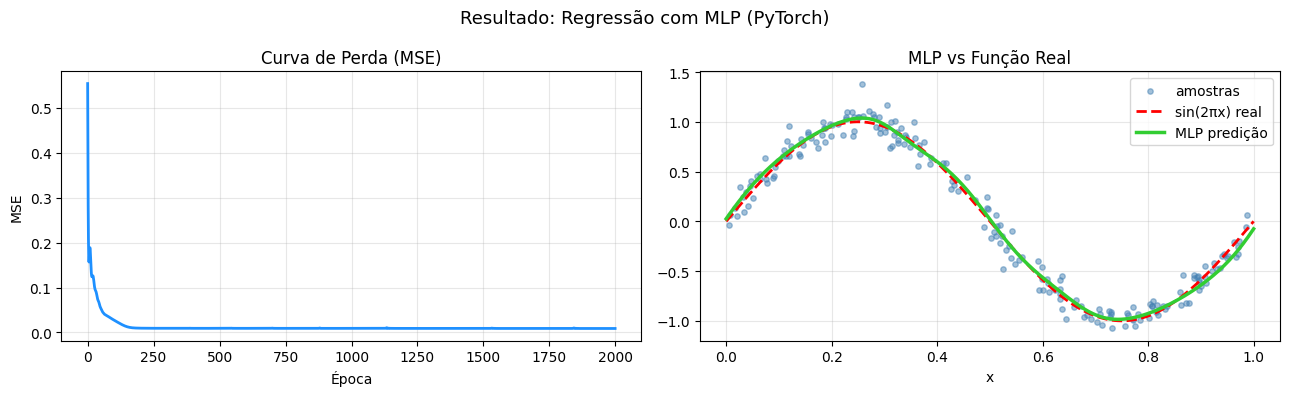

MSE final (MLP vs função real): 0.00155


In [7]:
# ── Visualização: Regressão ───────────────────────────────────────────────────
model_reg.eval()
with torch.no_grad():
    x_grid_n = torch.FloatTensor(np.linspace(X_reg_n.min(), X_reg_n.max(), 300).reshape(-1, 1))
    y_grid = model_reg(x_grid_n).numpy().ravel()

x_plot = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(historico_reg, color='#1E90FF', linewidth=2)
axes[0].set_title('Curva de Perda (MSE)', fontsize=12)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('MSE'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_reg, y_reg, s=15, alpha=0.5, color='steelblue', label='amostras')
axes[1].plot(x_plot, np.sin(2 * np.pi * x_plot), 'r--', linewidth=2, label='sin(2πx) real')
axes[1].plot(x_plot, y_grid, 'limegreen', linewidth=2.5, label='MLP predição')
axes[1].set_title('MLP vs Função Real', fontsize=12)
axes[1].set_xlabel('x'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Resultado: Regressão com MLP (PyTorch)', fontsize=13)
plt.tight_layout(); plt.show()

mse_final = np.mean((y_grid - np.sin(2 * np.pi * x_plot)) ** 2)
print(f"MSE final (MLP vs função real): {mse_final:.5f}")

---

## <span style="color:#1E90FF;">4. Exemplo 2: Classificação com MLP</span>

### Problema

Classificar pontos 2D que formam duas **luas** não-linearmente separáveis — o dataset *moons*.

Isso **não pode** ser resolvido por um único neurônio (regressão logística), pois as classes não são separáveis por uma reta.

### Arquitetura

```
Entrada (2) → Camada 1 (16 neurônios, Tanh) → Camada 2 (16 neurônios, Tanh) → Saída (1, Sigmoid)
```

### Função de Perda: Binary Cross-Entropy

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]$$

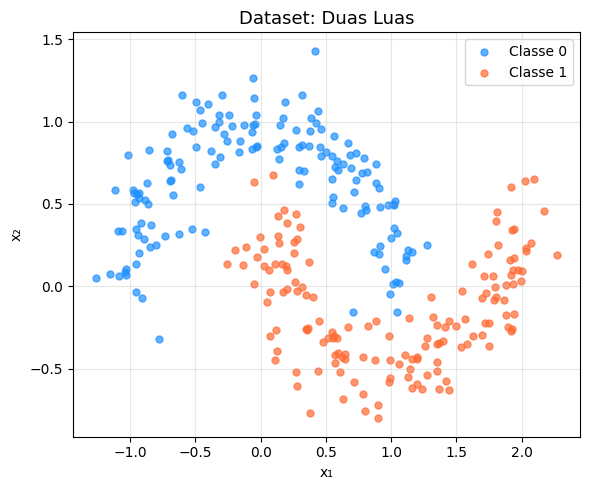

Dataset: 300 amostras — Classe 0: 150, Classe 1: 150


In [8]:
# ── Dataset: duas luas ────────────────────────────────────────────────────────
def make_moons(n=300, noise=0.15, seed=42):
    rng = np.random.default_rng(seed)
    n_half = n // 2
    angles0 = np.linspace(0, np.pi, n_half)
    X0 = np.c_[np.cos(angles0), np.sin(angles0)]
    angles1 = np.linspace(0, np.pi, n_half)
    X1 = np.c_[1 - np.cos(angles1), 1 - np.sin(angles1) - 0.5]
    X = np.vstack([X0, X1]) + rng.normal(0, noise, (n, 2))
    y = np.hstack([np.zeros(n_half), np.ones(n_half)])
    return X, y

X_cls, y_cls = make_moons(n=300, noise=0.15)
X_cls_n = (X_cls - X_cls.mean(axis=0)) / X_cls.std(axis=0)

plt.figure(figsize=(6, 5))
for label, cor, nome in [(0, '#1E90FF', 'Classe 0'), (1, '#FF6B35', 'Classe 1')]:
    mask = y_cls == label
    plt.scatter(X_cls[mask, 0], X_cls[mask, 1], s=25, alpha=0.7, color=cor, label=nome)
plt.title('Dataset: Duas Luas', fontsize=13)
plt.xlabel('x₁'); plt.ylabel('x₂'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Dataset: {len(y_cls)} amostras — Classe 0: {(y_cls==0).sum()}, Classe 1: {(y_cls==1).sum()}')

In [9]:
# ── MLP classificação com PyTorch ─────────────────────────────────────────────
class MLPCls(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1), nn.Sigmoid(),  # saída: probabilidade binária
        )

    def forward(self, x):
        return self.net(x)

# Converte dataset para tensores
X_ct = torch.FloatTensor(X_cls_n)                  # (300, 2)
y_ct = torch.FloatTensor(y_cls).unsqueeze(1)        # (300, 1)

model_cls = MLPCls()
print(model_cls)

MLPCls(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [10]:
# ── Treinamento: Classificação ────────────────────────────────────────────────
criterion_cls = nn.BCELoss()
optimizer_cls = optim.Adam(model_cls.parameters(), lr=1e-2)
historico_cls, historico_acc = [], []

for ep in range(2000):
    model_cls.train()
    y_pred = model_cls(X_ct)
    loss = criterion_cls(y_pred, y_ct)

    optimizer_cls.zero_grad()
    loss.backward()
    optimizer_cls.step()

    historico_cls.append(loss.item())
    acc = ((y_pred >= 0.5).float() == y_ct).float().mean().item() * 100
    historico_acc.append(acc)
    if (ep + 1) % 400 == 0:
        print(f"Época {ep+1:4d}/2000  |  BCE: {loss.item():.4f}  |  Acurácia: {acc:.1f}%")

Época  400/2000  |  BCE: 0.0039  |  Acurácia: 100.0%
Época  800/2000  |  BCE: 0.0007  |  Acurácia: 100.0%
Época 1200/2000  |  BCE: 0.0002  |  Acurácia: 100.0%
Época 1600/2000  |  BCE: 0.0001  |  Acurácia: 100.0%
Época 2000/2000  |  BCE: 0.0001  |  Acurácia: 100.0%


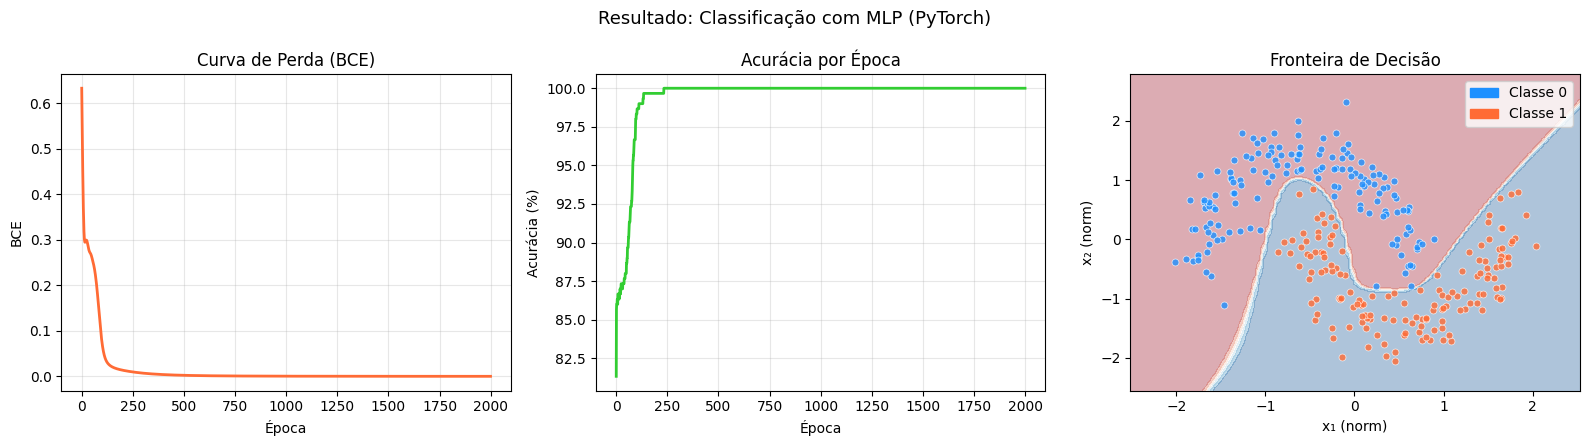

Acurácia final: 100.0%


In [11]:
# ── Visualização: Classificação ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(historico_cls, color='#FF6B35', linewidth=2)
axes[0].set_title('Curva de Perda (BCE)', fontsize=12)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('BCE'); axes[0].grid(True, alpha=0.3)

axes[1].plot(historico_acc, color='#32CD32', linewidth=2)
axes[1].set_title('Acurácia por Época', fontsize=12)
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Acurácia (%)'); axes[1].grid(True, alpha=0.3)

# Fronteira de decisão
h = 0.05
x1_min, x1_max = X_cls_n[:,0].min() - 0.5, X_cls_n[:,0].max() + 0.5
x2_min, x2_max = X_cls_n[:,1].min() - 0.5, X_cls_n[:,1].max() + 0.5
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
grid_input = torch.FloatTensor(np.c_[xx1.ravel(), xx2.ravel()])

model_cls.eval()
with torch.no_grad():
    Z_grid = model_cls(grid_input).numpy().reshape(xx1.shape)

axes[2].contourf(xx1, xx2, Z_grid, alpha=0.35, cmap='RdBu')
for label, cor in [(0, '#1E90FF'), (1, '#FF6B35')]:
    mask = y_cls == label
    axes[2].scatter(X_cls_n[mask, 0], X_cls_n[mask, 1], s=25, alpha=0.8,
                    color=cor, edgecolors='white', linewidths=0.5)
axes[2].set_title('Fronteira de Decisão', fontsize=12)
axes[2].set_xlabel('x₁ (norm)'); axes[2].set_ylabel('x₂ (norm)')
patches = [mpatches.Patch(color='#1E90FF', label='Classe 0'),
           mpatches.Patch(color='#FF6B35', label='Classe 1')]
axes[2].legend(handles=patches)

plt.suptitle('Resultado: Classificação com MLP (PyTorch)', fontsize=13)
plt.tight_layout(); plt.show()

model_cls.eval()
with torch.no_grad():
    preds_final = (model_cls(X_ct) >= 0.5).float().numpy().ravel()
print(f"Acurácia final: {(preds_final == y_cls).mean() * 100:.1f}%")

---

## <span style="color:#1E90FF;">5. Conclusão</span>

### Comparação dos dois exemplos

| Aspecto | Regressão | Classificação |
|---------|-----------|---------------|
| Saída | Valor contínuo $\hat{y} \in \mathbb{R}$ | Probabilidade $\hat{y} \in [0,1]$ |
| Ativação final | Linear (sem ativação) | Sigmoid |
| Função de perda | MSE: $(\hat{y} - y)^2$ | BCE: $-y\log\hat{y} - (1-y)\log(1-\hat{y})$ |
| Gradiente na saída | $2(\hat{y} - y)$ | $\hat{y} - y$ |
| Métrica de avaliação | MSE / RMSE | Acurácia / F1 |

### O que FNN/MLP pode e não pode fazer

| Consegue | Limitação |
|----------|-----------|
| Aproximar qualquer função contínua (Teorema Universal de Hornik) | Sem memória de sequências → use LSTM/RNN |
| Classificação binária e multiclasse | Não explora estrutura espacial 2D → use CNN |
| Regressão não-linear | Cresce quadraticamente com a entrada → use Embeddings |